# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Nanik Erawati
- **Email:** cdcc284d6x2024@student.devacademy.id
- **ID Dicoding:** CDCC284D6X2024

## Menentukan Pertanyaan Bisnis

- Kategori produk apa yang memiliki volume penjualan tertinggi dan mana yang menghasilkan pendapatan (revenue) paling besar?
- Pada jam dan hari apa pesanan paling banyak dilakukan oleh pelanggan?

## Import Semua Packages/Library yang Digunakan

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Mengatur tampilan seaborn agar visualisasi lebih menarik
sns.set(style='dark')

## Data Wrangling

### Gathering Data

In [96]:
# Tentukan folder utama dataset agar kode lebih pendek
path_dataset = "E-Commerce Public Dataset"

In [97]:
# Memuat dataset customers menggunakan path yang telah ditentukan
customers_df = pd.read_csv(os.path.join(path_dataset, "customers_dataset.csv"))

customers_df.shape

(99441, 5)

In [98]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [99]:
# Memuat dataset geolocation menggunakan path yang telah ditentukan
geolocation_df = pd.read_csv(os.path.join(path_dataset, "geolocation_dataset.csv"))

geolocation_df.shape


(1000163, 5)

In [100]:
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [101]:
# Memuat dataset order_items menggunakan path yang telah ditentukan
order_items_df = pd.read_csv(os.path.join(path_dataset, "order_items_dataset.csv"))

order_items_df.shape


(112650, 7)

In [102]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [103]:
# Memuat dataset order_payments menggunakan path yang telah ditentukan
order_payments_df = pd.read_csv(os.path.join(path_dataset, "order_payments_dataset.csv"))

order_payments_df.shape


(103886, 5)

In [104]:
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [105]:
# Memuat dataset order_reviews menggunakan path yang telah ditentukan
order_reviews_df = pd.read_csv(os.path.join(path_dataset, "order_reviews_dataset.csv"))

order_reviews_df.shape

(99224, 7)

In [106]:
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [107]:
# Memuat dataset orders menggunakan path yang telah ditentukan
orders_df = pd.read_csv(os.path.join(path_dataset, "orders_dataset.csv"))

orders_df.shape

(99441, 8)

In [108]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [109]:
# Memuat dataset product_category_name_translation menggunakan path yang telah ditentukan
product_category_df = pd.read_csv(os.path.join(path_dataset, "product_category_name_translation.csv"))

product_category_df.shape

(71, 2)

In [110]:
product_category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [111]:
# Memuat dataset products menggunakan path yang telah ditentukan
products_df = pd.read_csv(os.path.join(path_dataset, "products_dataset.csv"))

products_df.shape

(32951, 9)

In [112]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [113]:
# Memuat dataset sellers menggunakan path yang telah ditentukan
sellers_df = pd.read_csv(os.path.join(path_dataset, "sellers_dataset.csv"))

sellers_df.shape

(3095, 4)

In [114]:
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**

Berdasarkan gathering data di atas, berikut insight yang bisa saya dapatakan:

#### **1. Ringkasan Dataset yang Berhasil Dimuat**

| Dataset | Jumlah Baris | Jumlah Kolom | Keterangan |
| :--- | :--- | :--- | :--- |
| **customers_df** | 99.441 | 5 | Data pelanggan unik beserta lokasi |
| **geolocation_df** | 1.000.163 | 5 | Koordinat geografis per kode pos |
| **order_items_df** | 112.650 | 7 | Detail item per pesanan (harga, freight) |
| **order_payments_df** | 103.886 | 5 | Metode & nilai pembayaran |
| **order_reviews_df** | 99.224 | 7 | Ulasan & skor kepuasan pelanggan |
| **orders_df** | 99.441 | 8 | Status & timestamp pesanan |
| **product_category_df** | 71 | 2 | Terjemahan nama kategori PT→EN |
| **products_df** | 32.951 | 9 | Atribut fisik & kategori produk |
| **sellers_df** | 3.095 | 4 | Lokasi penjual |

#### **2. Kolom Kunci yang Teridentifikasi**
* **`order_id`** : penghubung antara orders, order_items, order_payments, order_reviews
* **`product_id`** : penghubung antara order_items dan products
* **`product_category_name`** : penghubung antara products dan product_category (terjemahan)
* **`order_purchase_timestamp`** : kolom utama untuk analisis waktu (jam & hari)
* **`price`** : kolom utama untuk perhitungan revenue

#### **3. Dataset yang Relevan dengan Pertanyaan Bisnis**
* **Pertanyaan 1 (volume & revenue per kategori):** `order_items_df`, `products_df`, `product_category_df`, dan `orders_df` (untuk filter status)
* **Pertanyaan 2 (jam & hari paling aktif):** cukup `orders_df` kolom `order_purchase_timestamp`

#### **4. Dataset yang Tidak Digunakan Langsung**
* `geolocation_df`, `order_payments_df`, `order_reviews_df`, `sellers_df`, `customers_df` tidak relevan dengan kedua pertanyaan bisnis yang telah didefinisikan.

### Assessing Data

Order_Items Dataset

In [115]:
# Struktur Data & Tipe Data pada Dataset order_items
print("--- Struktur Data ---")
order_items_df.info()

--- Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [116]:
# Cek Missing Values pada Dataset order_items
print("\n--- Missing Values ---")
print(order_items_df.isnull().sum())


--- Missing Values ---
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [117]:
# Cek Duplikasi pada Dataset order_items
print("\n--- Duplikasi ---")
print(f"Jumlah duplikasi: {order_items_df.duplicated().sum()}")


--- Duplikasi ---
Jumlah duplikasi: 0


In [118]:
#Statistik Deskriptif pada Dataset order_items
print("\n--- Statistik Deskriptif ---")
display(order_items_df.describe())


--- Statistik Deskriptif ---


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


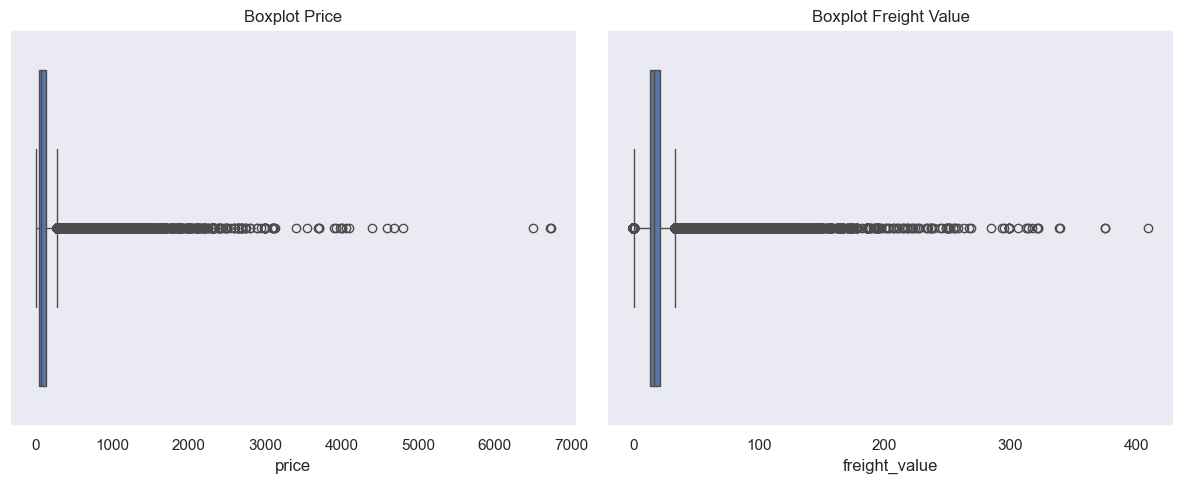

In [119]:
# Deteksi outlier untuk Price dan Freight Value
# Menyiapkan kanvas dengan 1 baris dan 2 kolom
plt.figure(figsize=(12, 5))

# Boxplot untuk Price
plt.subplot(1, 2, 1)
sns.boxplot(x=order_items_df['price'])
plt.title('Boxplot Price')

# Boxplot untuk Freight Value
plt.subplot(1, 2, 2)
sns.boxplot(x=order_items_df['freight_value'])
plt.title('Boxplot Freight Value')

plt.tight_layout()
plt.show()

Products Dataset

In [120]:
# Struktur Data & Tipe Data pada Dataset products
print("--- Struktur Data ---")  
print(products_df.info())

--- Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
None


In [121]:
# cek missing values pada dataset products
print("\n--- Missing Values ---")
print(products_df.isnull().sum())


--- Missing Values ---
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [122]:
# Cek Duplikasi pada Dataset products
print("\n--- Duplikasi ---")
print(f"Jumlah duplikasi: {products_df.duplicated().sum()}")


--- Duplikasi ---
Jumlah duplikasi: 0


In [123]:
# Statistik Deskriptif pada Dataset products
print("\n--- Statistik Deskriptif ---")
display(products_df.describe())


--- Statistik Deskriptif ---


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


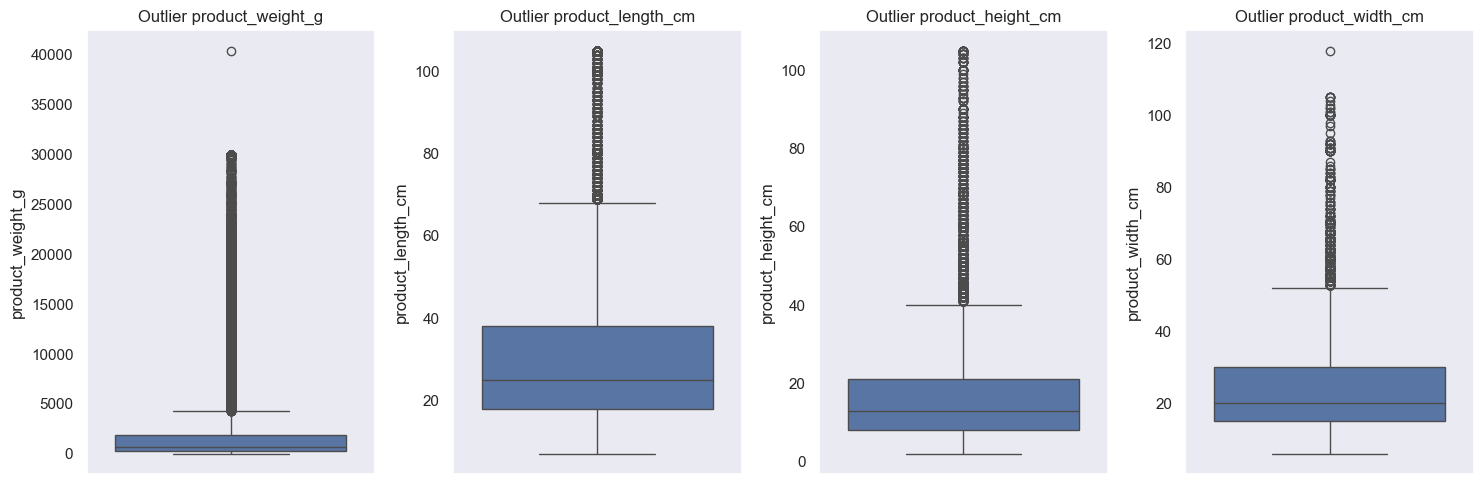

In [124]:
# Cek Outlier pada Dataset products menggunakan Boxplot
# Kolom numerik di dataset products
num_cols_products = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols_products):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(y=products_df[col])
    plt.title(f'Outlier {col}')

plt.tight_layout()
plt.show()

product_category Dataset

In [125]:
# Struktur Data & Tipe Data pada Dataset product_category
print("--- Struktur Data ---")
print(product_category_df.info())

--- Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
None


In [126]:
# Cek Missing Values pada Dataset product_category
print("\n--- Missing Values ---")
print(product_category_df.isnull().sum())


--- Missing Values ---
product_category_name            0
product_category_name_english    0
dtype: int64


In [127]:
# Cek duplikasi pada Dataset product_category
print("\n--- Duplikasi ---")
print(f"Jumlah duplikasi: {product_category_df.duplicated().sum()}")


--- Duplikasi ---
Jumlah duplikasi: 0


In [128]:
# Statistik Deskriptif pada Dataset product_category
print("\n--- Statistik Deskriptif ---")
display(product_category_df.describe())


--- Statistik Deskriptif ---


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


orders Dataset

In [129]:
# Struktur Data & Tipe Data pada Dataset orders
print("--- Struktur Data ---")  
print(orders_df.info())

--- Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None


In [130]:
# Cek Missing Values pada Dataset orders
print("\n--- Missing Values ---")   
print(orders_df.isnull().sum())


--- Missing Values ---
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [131]:
# cek duplikasi pada dataset orders
print("\n--- Duplikasi ---")
print(f"Jumlah duplikasi: {orders_df.duplicated().sum()}")


--- Duplikasi ---
Jumlah duplikasi: 0


In [132]:
# Statistik Deskriptif pada Dataset orders
print("\n--- Statistik Deskriptif ---")
display(orders_df.describe())


--- Statistik Deskriptif ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight:**

#### **1. Masalah Tipe Data**
* **orders_df**: Semua kolom *timestamp* (`order_purchase_timestamp`, `order_approved_at`, dll.) terdeteksi bertipe `object`. Kolom-kolom ini harus dikonversi ke tipe `datetime`.
* **order_items_df**: Kolom `shipping_limit_date` bertipe `object` dan harus dikonversi ke tipe `datetime`.

#### **2. Missing Values**

| Dataset | Kolom | Jumlah Kosong | Kemungkinan Penyebab |
| :--- | :--- | :--- | :--- |
| **orders_df** | `order_approved_at` | 160 | Pesanan belum/tidak diapprove |
| **orders_df** | `order_delivered_carrier_date` | 1.783 | Pesanan belum dikirim kurir |
| **orders_df** | `order_delivered_customer_date` | 2.965 | Pesanan belum sampai ke pelanggan |
| **products_df** | `product_category_name` | 610 | Produk tanpa kategori |
| **products_df** | `product_weight_g` dst | 2 | Data dimensi fisik tidak lengkap |

#### **3. Duplikasi**
* Tidak ditemukan duplikasi di semua dataset. 

#### **4. Analisis statistik**
Sebagian besar outlier yang ditemukan **TIDAK perlu ditangani** dengan alasan logika bisnis berikut:
* **price** (max: 6.735 BRL): Valid, karena e-commerce menjual produk premium (elektronik/furnitur).
* **freight_value** (max: 409 BRL): Valid untuk pengiriman barang berat ke wilayah terpencil di Brasil.
* **product_weight_g** (max: ~40 kg): Valid untuk produk kategori peralatan rumah tangga besar.
* **Dimensi Produk**: Valid untuk ukuran produk besar (furnitur).

**Kesimpulan Outlier:** Nilai ekstrem merupakan nilai valid, bukan kesalahan data. Menghapusnya justru akan menghilangkan informasi penting. Satu-satunya anomali yang perlu ditangani adalah `product_weight_g` bernilai **0**, karena produk fisik tidak mungkin tanpa berat.

---

### **Action Plan untuk Cleaning Data**

| No | Masalah | Penanganan |
| :--- | :--- | :--- |
| 1 | Kolom datetime masih `object` | Konversi menggunakan `pd.to_datetime()` |
| 2 | Missing values di `orders` (NaT) | Biarkan sebagai `NaT` (merepresentasikan pesanan belum selesai) |
| 3 | Missing `product_category_name` | Isi dengan label **"unknown"** |
| 4 | Missing dimensi fisik (2 baris) | Imputasi menggunakan nilai **median** |
| 5 | `product_weight_g` = 0 | Ganti 0 dengan `NaN` lalu imputasi dengan **median** |
| 6 | Outlier price, freight, dimensi | **Tidak ditangani** (nilai dianggap valid secara bisnis) |

### Cleaning Data

In [171]:
# Mengonversi kolom waktu di dataset orders_df

orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])

# Verifikasi hasil konversi
print("--- Verifikasi Tipe Data orders_df ---")
print(orders_df.dtypes)

--- Verifikasi Tipe Data orders_df ---
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [172]:
# Mengonversi kolom waktu di dataset order_items_df
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

# Verifikasi hasil konversi
print("\n--- Verifikasi Tipe Data order_items_df ---")
print(order_items_df['shipping_limit_date'].dtype)


--- Verifikasi Tipe Data order_items_df ---
datetime64[ns]


In [173]:
# Missing Values orders_df — Biarkan sebagai NaT
# Tidak perlu kode khusus karena pd.to_datetime() otomatis mengubah nilai kosong menjadi NaT Cukup verifikasi saja

print("Missing values setelah konversi:")
print(orders_df.isnull().sum())

Missing values setelah konversi:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [174]:
# Menangani missing values pada dataset products --- Mengisi missing values pada kolom product_category_name dengan "unknown"
products_df["product_category_name"].fillna("unknown", inplace=True)

# Verifikasi
print(f"Missing values tersisa: {products_df['product_category_name'].isnull().sum()}")

Missing values tersisa: 0


In [175]:
# Menangani missing values pada dataset product_category --- Mengisi missing values pada kolom product_category_name_english dengan "unknown"
physical_cols = [
    "product_weight_g", 
    "product_length_cm", 
    "product_height_cm", 
    "product_width_cm"
]

for col in physical_cols:
    products_df[col].fillna(products_df[col].median(), inplace=True)

# Verifikasi
print(products_df[physical_cols].isnull().sum())

product_weight_g     0
product_length_cm    0
product_height_cm    0
product_width_cm     0
dtype: int64


In [176]:
# Menangani nilai 0.0 pada kolom dimensi fisik dengan menggantinya dengan median
# Ubah 0 menjadi NaN dulu
products_df["product_weight_g"] = products_df["product_weight_g"].replace(0.0, np.nan)

# Isi dengan median
products_df["product_weight_g"].fillna(products_df["product_weight_g"].median(), inplace=True)

# Verifikasi — pastikan minimum bukan lagi 0
print(f"Berat minimum setelah cleaning: {products_df['product_weight_g'].min()}")

Berat minimum setelah cleaning: 2.0


**Insight:**

Berdasarkan proses pembersihan yang telah dilakukan, berikut adalah ringkasan hasilnya:

#### **1. Perbaikan yang Dilakukan**
* **Konversi Tipe Data**: Sebanyak 6 kolom *datetime* berhasil dikonversi dari tipe `object` ke `datetime64` untuk memastikan keakuratan analisis berbasis waktu.
* **Penanganan Missing Values (Kategori)**: Sebanyak **610 produk** tanpa kategori telah diberi label **"unknown"**. Hal ini dilakukan agar data tersebut tetap dapat diikutsertakan dalam proses agregasi tanpa menyebabkan error.
* **Imputasi Dimensi Fisik**: Terdapat 2 baris data dimensi fisik yang kosong dan telah berhasil diimputasi menggunakan nilai **median**.
* **Perbaikan Anomali Berat**: Ditemukan anomali di mana berat produk bernilai **0 gram**. Masalah ini telah diperbaiki dengan metode imputasi **median**.

#### **2. Data yang Dipertahankan (Tanpa Perubahan)**
* **Status Pengiriman (NaT)**: Nilai `NaT` pada kolom pengiriman di `orders_df` sengaja dibiarkan karena secara akurat merepresentasikan pesanan yang memang belum selesai diproses.
* **Nilai Ekstrem (Outlier)**: Outlier pada kolom `price`, `freight_value`, dan dimensi produk **tidak dihapus**. Setelah diverifikasi secara logika bisnis, nilai-nilai tersebut terbukti valid dan penting untuk analisis produk.

---
**Status Akhir:** Semua dataset telah dinyatakan bersih (*Cleaned*) dan siap untuk digunakan dalam tahap **Exploratory Data Analysis (EDA)**.

## Exploratory Data Analysis (EDA)

### Explore ...

In [177]:
# Gabung orders + order_items
orders_items_merged = pd.merge(
    left=orders_df,
    right=order_items_df,
    how="inner",        # inner karena kita hanya butuh pesanan yang punya item
    on="order_id"
)

orders_items_merged.head()



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [178]:
# Gabung dengan products
main_products_merged = pd.merge(
    left=orders_items_merged,
    right=products_df,
    how="left",
    on="product_id"
)

main_products_merged.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [180]:
# Gabung dengan terjemahan kategori
all_df = pd.merge(
    left= main_products_merged,
    right=product_category_df,
    how="left",
    on="product_category_name"
)

print(all_df.shape)
all_df.head()

(112650, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [181]:
# Cek status pesanan yang ada
print(all_df["order_status"].value_counts())

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64


In [183]:
# Melihat ringkasan data akhir# Hanya ambil pesanan yang sudah delivered
# karena ini yang benar-benar terjadi transaksinya
df_delivered = all_df[all_df["order_status"] == "delivered"].copy()

print(f"Jumlah baris sebelum filter: {len(all_df)}")
print(f"Jumlah baris setelah filter: {len(df_delivered)}")
print(df_delivered.info())

Jumlah baris sebelum filter: 112650
Jumlah baris setelah filter: 110197
<class 'pandas.core.frame.DataFrame'>
Index: 110197 entries, 0 to 112649
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110195 non-null  datetime64[ns]
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110197 non-null  datetime64[ns]
 8   order_item_id                  110197 non-null  int64         
 9   product_id                     110197 non-null  object        
 10  s

In [184]:
# Pilih kolom yang relevan untuk analisis selanjutnya
df_clean = df_delivered[[
    "order_id",
    "order_purchase_timestamp",
    "order_status",
    "product_id",
    "product_category_name_english",
    "price",
    "freight_value"
]].copy()

# Cek missing values setelah merge
print(df_clean.isnull().sum())

# Isi kategori yang masih kosong setelah merge
df_clean["product_category_name_english"].fillna("others", inplace=True)

print(df_clean.shape)
df_clean.head()

order_id                            0
order_purchase_timestamp            0
order_status                        0
product_id                          0
product_category_name_english    1559
price                               0
freight_value                       0
dtype: int64
(110197, 7)


,order_id,order_purchase_timestamp,order_status,product_id,product_category_name_english,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,delivered,87285b34884572647811a353c7ac498a,housewares,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,delivered,595fac2a385ac33a80bd5114aec74eb8,perfumery,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,delivered,aa4383b373c6aca5d8797843e5594415,auto,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,delivered,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,delivered,65266b2da20d04dbe00c5c2d3bb7859e,stationery,19.90,8.72


In [185]:
# Agregasi per kategori
product_performance = df_clean.groupby("product_category_name_english").agg(
    order_count=("order_id", "nunique"),
    revenue=("price", "sum")
).reset_index()

# Top 10 volume
top_volume = product_performance.sort_values("order_count", ascending=False).head(10)
print("Top 10 Kategori - Volume Penjualan:")
print(top_volume)

Top 10 Kategori - Volume Penjualan:
   product_category_name_english  order_count     revenue
7                 bed_bath_table         9272  1023434.76
43                 health_beauty         8647  1233131.72
66                sports_leisure         7530   954852.55
15         computers_accessories         6530   888724.61
39               furniture_decor         6307   711927.69
49                    housewares         5743   615628.69
71                 watches_gifts         5495  1166176.98
69                     telephony         4093   309860.23
5                           auto         3810   578966.65
70                          toys         3804   471286.48


In [186]:
# Top 10 revenue
top_revenue = product_performance.sort_values("revenue", ascending=False).head(10)
print("\nTop 10 Kategori - Revenue:")
print(top_revenue)


Top 10 Kategori - Revenue:
   product_category_name_english  order_count     revenue
43                 health_beauty         8647  1233131.72
71                 watches_gifts         5495  1166176.98
7                 bed_bath_table         9272  1023434.76
66                sports_leisure         7530   954852.55
15         computers_accessories         6530   888724.61
39               furniture_decor         6307   711927.69
49                    housewares         5743   615628.69
20                    cool_stuff         3559   610204.10
5                           auto         3810   578966.65
70                          toys         3804   471286.48


In [187]:
# Ekstrak jam, hari, dan bulan dari timestamp
df_clean["order_hour"] = df_clean["order_purchase_timestamp"].dt.hour
df_clean["order_day"] = df_clean["order_purchase_timestamp"].dt.day_name()
df_clean["order_month"] = df_clean["order_purchase_timestamp"].dt.month_name()

print(df_clean.head())

                           order_id order_purchase_timestamp order_status  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33    delivered   
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37    delivered   
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49    delivered   
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06    delivered   
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39    delivered   

                         product_id product_category_name_english   price  \
0  87285b34884572647811a353c7ac498a                    housewares   29.99   
1  595fac2a385ac33a80bd5114aec74eb8                     perfumery  118.70   
2  aa4383b373c6aca5d8797843e5594415                          auto  159.90   
3  d0b61bfb1de832b15ba9d266ca96e5b0                      pet_shop   45.00   
4  65266b2da20d04dbe00c5c2d3bb7859e                    stationery   19.90   

   freight_value  order_hour  order_day order_month  
0           8.72    

In [188]:
# Eksplorasi per jam
hourly_orders = df_clean.groupby("order_hour")["order_id"].nunique().reset_index()
hourly_orders.rename(columns={"order_id": "order_count"}, inplace=True)

print("Pesanan per jam:")
print(hourly_orders.sort_values("order_count", ascending=False).head(5))


Pesanan per jam:
    order_hour  order_count
16          16         6476
11          11         6385
14          14         6383
13          13         6309
15          15         6249


In [189]:
# Eksplorasi per hari
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_orders = df_clean.groupby("order_day")["order_id"].nunique().reindex(days_order).reset_index()
daily_orders.rename(columns={"order_id": "order_count"}, inplace=True)

print("\nPesanan per hari:")
print(daily_orders)


Pesanan per hari:
   order_day  order_count
0     Monday        15701
1    Tuesday        15503
2  Wednesday        15076
3   Thursday        14323
4     Friday        13685
5   Saturday        10555
6     Sunday        11635


In [191]:
# Simpan dataset akhir ke dalam format CSV untuk dashboard
df_clean.to_csv("main_data.csv", index=False)
print("Dataset berhasil disimpan!")

Dataset berhasil disimpan!


**Insight:**

Berdasarkan eksplorasi data yang telah dilakukan, berikut adalah temuan utama yang didapatkan:

#### **Pertanyaan 1:**
* Terdapat perbedaan antara kategori paling laku (volume) dan paling menguntungkan (revenue).
* Kategori seperti **`bed_bath_table`** mendominasi volume karena merupakan kebutuhan rumah tangga sehari-hari.
* Kategori seperti **`health_beauty`** dan **`watches_gifts`** unggul di revenue karena harga per unitnya lebih tinggi.

#### **Pertanyaan 2:**
* Pesanan paling banyak terjadi di rentang pukul **10:00–17:00** (jam produktif).
* Hari **Senin dan Selasa** adalah hari paling aktif.
* Aktivitas pemesanan menurun signifikan di akhir pekan, mengindikasikan pelanggan mayoritas berbelanja di hari kerja.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

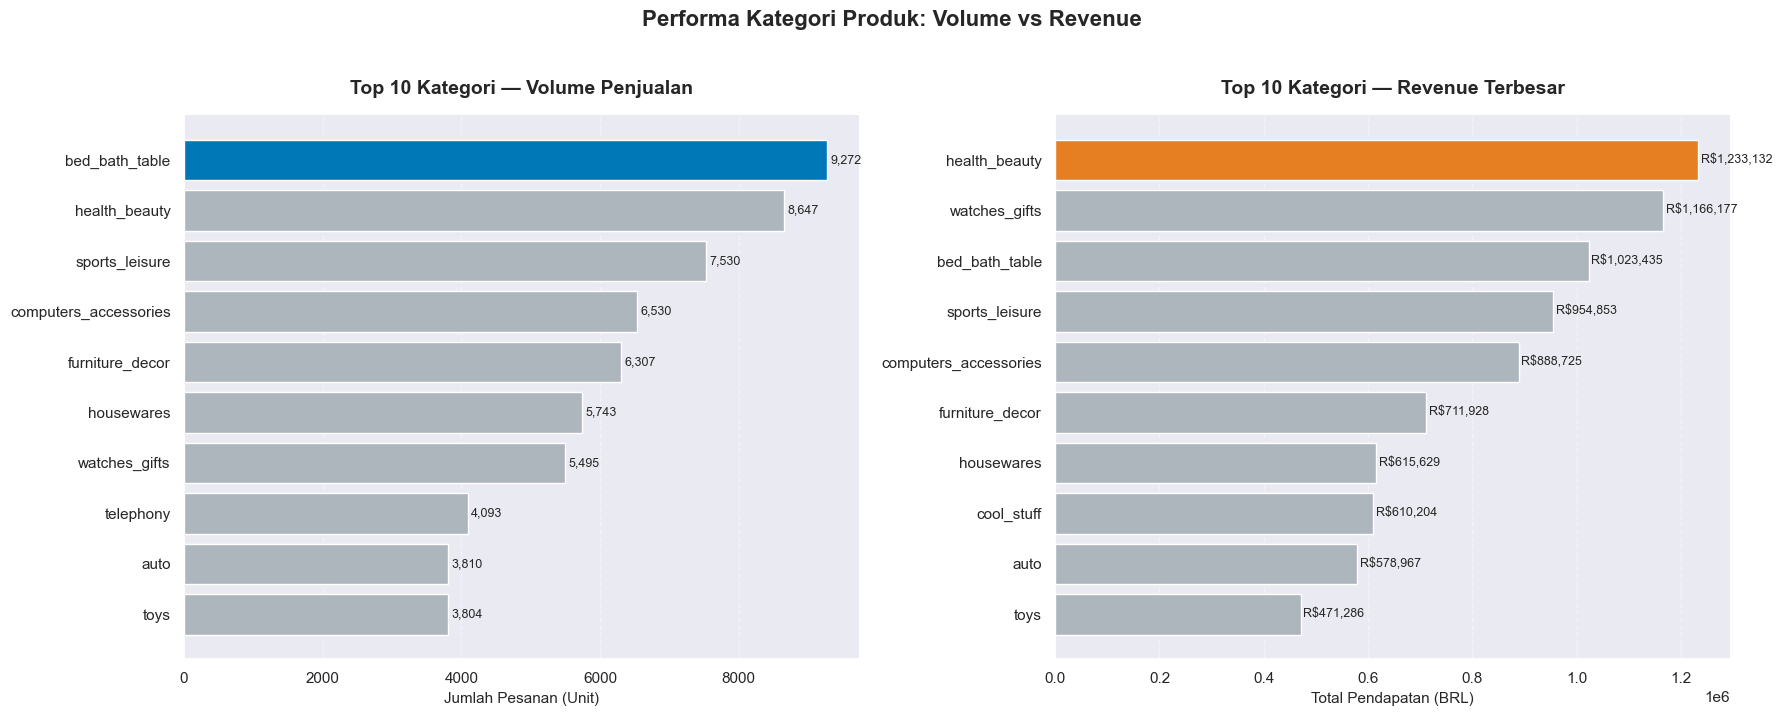

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Grafik Kiri: Top 10 Volume ---
top_10_volume = product_performance.sort_values("order_count", ascending=False).head(10)

colors_vol = ["#0077b6" if i == 0 else "#adb5bd" for i in range(len(top_10_volume))]

axes[0].barh(
    top_10_volume["product_category_name_english"][::-1],
    top_10_volume["order_count"][::-1],
    color=colors_vol[::-1]
)
axes[0].set_title("Top 10 Kategori — Volume Penjualan", fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("Jumlah Pesanan (Unit)", fontsize=11)
axes[0].set_ylabel(None)
axes[0].grid(axis="x", linestyle="--", alpha=0.4)
axes[0].spines[["top", "right"]].set_visible(False)

# Tambahkan label nilai di ujung bar
for i, v in enumerate(top_10_volume["order_count"][::-1]):
    axes[0].text(v + 50, i, f"{v:,}", va="center", fontsize=9)

# --- Grafik Kanan: Top 10 Revenue ---
top_10_revenue = product_performance.sort_values("revenue", ascending=False).head(10)

colors_rev = ["#e67e22" if i == 0 else "#adb5bd" for i in range(len(top_10_revenue))]

axes[1].barh(
    top_10_revenue["product_category_name_english"][::-1],
    top_10_revenue["revenue"][::-1],
    color=colors_rev[::-1]
)
axes[1].set_title("Top 10 Kategori — Revenue Terbesar", fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("Total Pendapatan (BRL)", fontsize=11)
axes[1].set_ylabel(None)
axes[1].grid(axis="x", linestyle="--", alpha=0.4)
axes[1].spines[["top", "right"]].set_visible(False)

# Tambahkan label nilai di ujung bar
for i, v in enumerate(top_10_revenue["revenue"][::-1]):
    axes[1].text(v + 5000, i, f"R${v:,.0f}", va="center", fontsize=9)

plt.suptitle("Performa Kategori Produk: Volume vs Revenue", 
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



### Pertanyaan 2:

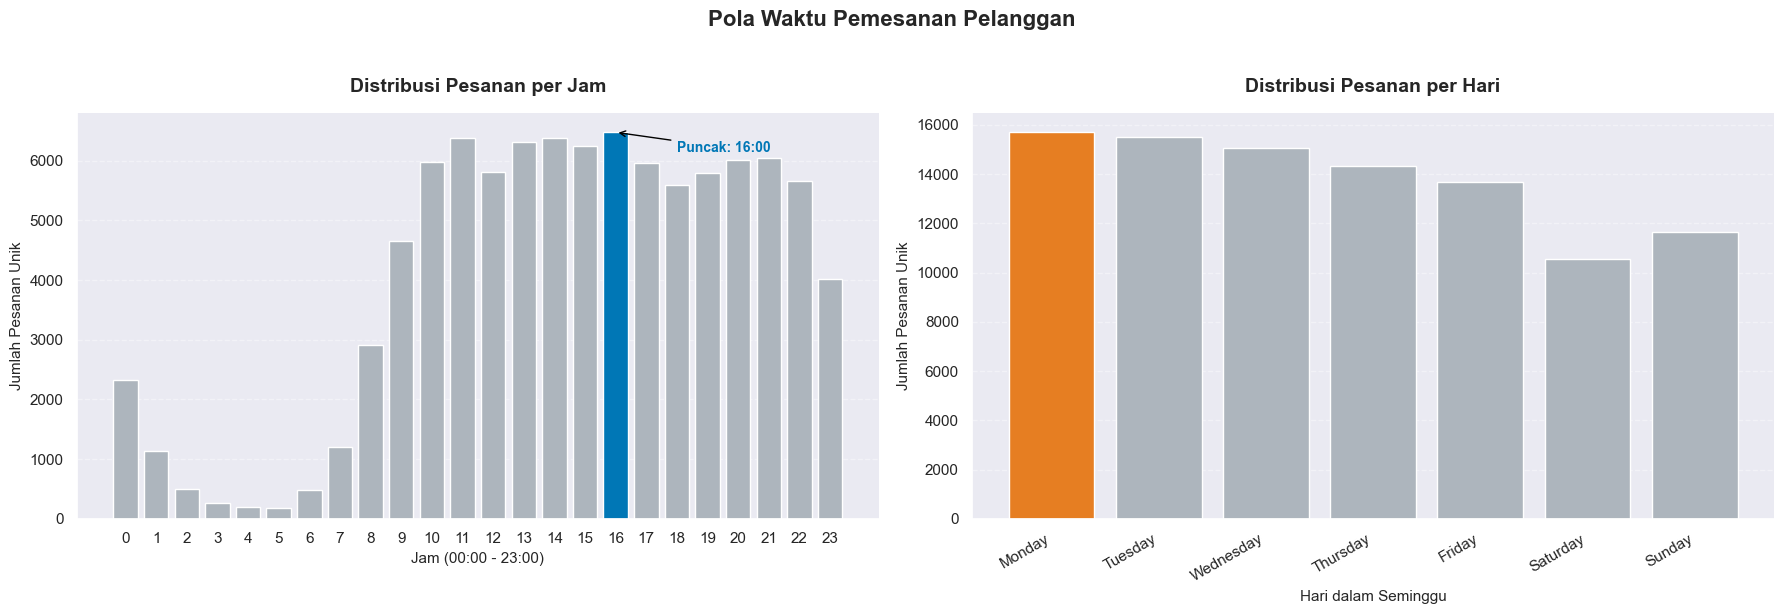

In [193]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Grafik Kiri: Per Jam ---
peak_hour = hourly_orders.loc[hourly_orders["order_count"].idxmax(), "order_hour"]

colors_hour = ["#0077b6" if h == peak_hour else "#adb5bd" 
               for h in hourly_orders["order_hour"]]

axes[0].bar(
    hourly_orders["order_hour"],
    hourly_orders["order_count"],
    color=colors_hour
)
axes[0].set_title("Distribusi Pesanan per Jam", fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("Jam (00:00 - 23:00)", fontsize=11)
axes[0].set_ylabel("Jumlah Pesanan Unik", fontsize=11)
axes[0].set_xticks(range(0, 24))
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].spines[["top", "right"]].set_visible(False)

# Anotasi jam puncak
axes[0].annotate(
    f"Puncak: {peak_hour:02d}:00",
    xy=(peak_hour, hourly_orders.loc[hourly_orders["order_hour"] == peak_hour, "order_count"].values[0]),
    xytext=(peak_hour + 2, hourly_orders["order_count"].max() * 0.95),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10, color="#0077b6", fontweight="bold"
)

# --- Grafik Kanan: Per Hari ---
peak_day = daily_orders.loc[daily_orders["order_count"].idxmax(), "order_day"]

colors_day = ["#e67e22" if d == peak_day else "#adb5bd" 
              for d in daily_orders["order_day"]]

axes[1].bar(
    daily_orders["order_day"],
    daily_orders["order_count"],
    color=colors_day
)
axes[1].set_title("Distribusi Pesanan per Hari", fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("Hari dalam Seminggu", fontsize=11)
axes[1].set_ylabel("Jumlah Pesanan Unik", fontsize=11)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)
axes[1].spines[["top", "right"]].set_visible(False)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.suptitle("Pola Waktu Pemesanan Pelanggan", 
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

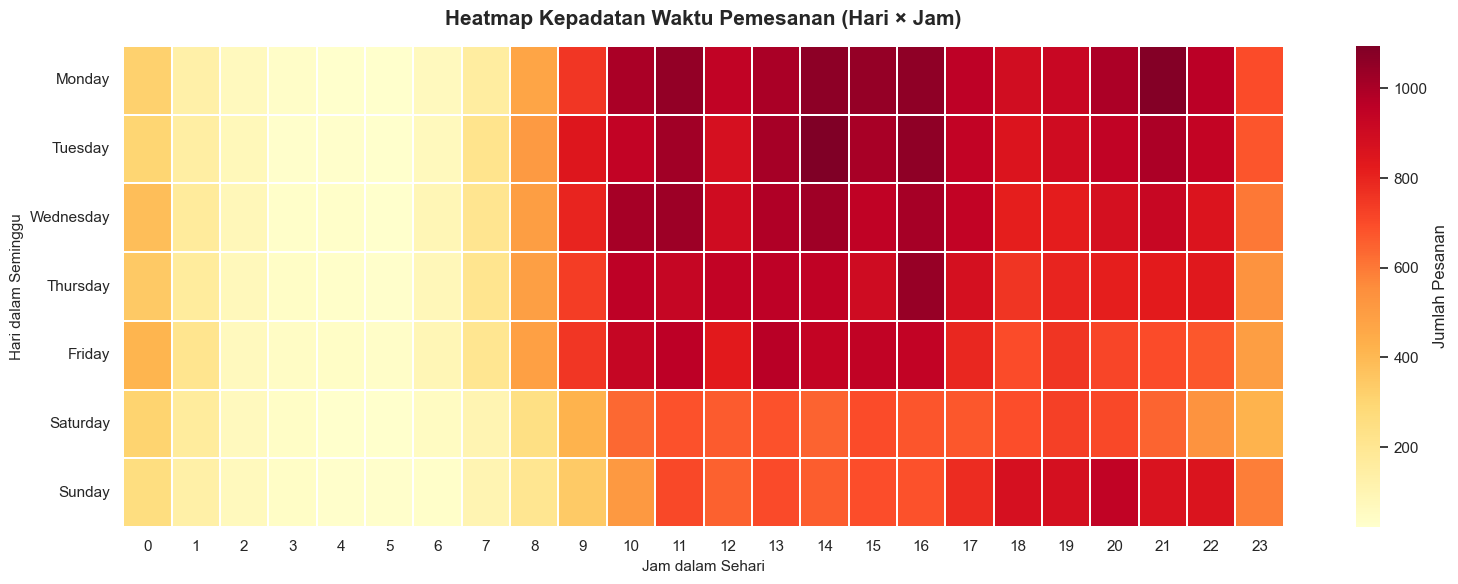

In [194]:
# Buat pivot table
heatmap_data = df_clean.groupby(
    ["order_day", "order_hour"]
)["order_id"].nunique().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Jumlah Pesanan"}
)
plt.title("Heatmap Kepadatan Waktu Pemesanan (Hari × Jam)", 
          fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Jam dalam Sehari", fontsize=11)
plt.ylabel("Hari dalam Seminggu", fontsize=11)
plt.tight_layout()
plt.show()

**Insight:**

#### **Pertanyaan 1 — Volume vs Revenue:**
* **`bed_bath_table`** memimpin volume penjualan dengan selisih jauh dari kategori lain, menunjukkan produk rumah tangga adalah penggerak utama transaksi harian.
* Namun dari sisi revenue, **`health_beauty`** dan **`watches_gifts`** justru lebih unggul karena harga per unitnya jauh lebih tinggi.
* **Implikasi bisnis:** Strategi promosi sebaiknya dibedakan — *volume-driven category* butuh ketersediaan stok, sementara *revenue-driven category* butuh strategi *upselling* dan *premium positioning*.

#### **Pertanyaan 2 — Waktu Pemesanan:**
* Puncak pemesanan terjadi antara pukul **10:00–17:00**, dengan jam tertinggi di sekitar **14:00–16:00**.
* Hari **Senin dan Selasa** paling aktif, sementara **Sabtu dan Minggu** paling sepi.
* **Implikasi bisnis:** Jadwalkan kampanye iklan, *flash sale*, dan *push notification* di rentang waktu tersebut untuk memaksimalkan konversi.

## Analisis Lanjutan (Opsional)

In [201]:
# Load data bersih
df_clean = pd.read_csv("main_data.csv", parse_dates=["order_purchase_timestamp"])

# Perlu customer_id — gabung dari orders_dataset asli
orders_df = pd.read_csv(os.path.join(path_dataset, "orders_dataset.csv"))

df_rfm_base = df_clean.merge(
    orders_df[["order_id", "customer_id"]],
    on="order_id",
    how="left"
)

print(df_rfm_base[["order_id", "customer_id", "order_purchase_timestamp", "price"]].head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_purchase_timestamp   price  
0      2017-10-02 10:56:33   29.99  
1      2018-07-24 20:41:37  118.70  
2      2018-08-08 08:38:49  159.90  
3      2017-11-18 19:28:06   45.00  
4      2018-02-13 21:18:39   19.90  


In [202]:
# Tentukan tanggal referensi untuk perhitungan Recency
#  Gunakan tanggal maksimum + 1 hari sebagai "hari ini"
reference_date = df_rfm_base["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
print(f"Tanggal referensi: {reference_date.date()}")

Tanggal referensi: 2018-08-30


In [203]:
# Hitung RFM per customer
rfm = df_rfm_base.groupby("customer_id").agg(
    recency=("order_purchase_timestamp", lambda x: (reference_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("price", "sum")
).reset_index()

print(rfm.describe())
print(rfm.shape)
rfm.head()

            recency  frequency      monetary
count  96478.000000    96478.0  96478.000000
mean     240.121364        1.0    137.041586
std      152.836972        0.0    209.045198
min        1.000000        1.0      0.850000
25%      116.000000        1.0     45.900000
50%      221.000000        1.0     86.575000
75%      350.000000        1.0    149.900000
max      714.000000        1.0  13440.000000
(96478, 4)


,customer_id,recency,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,288,1,89.80
1,000161a058600d5901f007fab4c27140,410,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,548,1,179.99
3,0002414f95344307404f0ace7a26f1d5,379,1,149.90
4,000379cdec625522490c315e70c7a9fb,150,1,93.00


In [204]:
# Scoring RFM (skala 1-5)
# Recency: semakin kecil = semakin baik → skor terbalik
rfm["R_score"] = pd.qcut(rfm["recency"], q=5, labels=[5, 4, 3, 2, 1])

# Frequency & Monetary: semakin besar = semakin baik
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])
rfm["M_score"] = pd.qcut(rfm["monetary"], q=5, labels=[1, 2, 3, 4, 5])

# Konversi ke integer
rfm[["R_score", "F_score", "M_score"]] = rfm[["R_score", "F_score", "M_score"]].astype(int)

# Gabungkan jadi RFM_score total
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

print(rfm[["customer_id", "recency", "frequency", "monetary", "R_score", "F_score", "M_score", "RFM_score"]].head(10))

                        customer_id  recency  frequency  monetary  R_score  \
0  00012a2ce6f8dcda20d059ce98491703      288          1     89.80        2   
1  000161a058600d5901f007fab4c27140      410          1     54.90        1   
2  0001fd6190edaaf884bcaf3d49edf079      548          1    179.99        1   
3  0002414f95344307404f0ace7a26f1d5      379          1    149.90        2   
4  000379cdec625522490c315e70c7a9fb      150          1     93.00        4   
5  0004164d20a9e969af783496f3408652      505          1     59.99        1   
6  000419c5494106c306a97b5635748086      180          1     34.30        4   
7  00046a560d407e99b969756e0b10f282      255          1    120.90        3   
8  00050bf6e01e69d5c0fd612f1bcfb69c      346          1     69.99        2   
9  000598caf2ef4117407665ac33275130       19          1   1107.00        5   

   F_score  M_score  RFM_score  
0        1        3          6  
1        1        2          4  
2        1        5          7  
3        

In [205]:
# Segmentasi pelanggan berdasarkan RFM
def segment_customer(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    score = row["RFM_score"]
    
    if r >= 4 and f >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "Recent Customers"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2 and m >= 4:
        return "Lost High Value"
    elif score >= 11:
        return "Potential Loyalist"
    elif score >= 7:
        return "Needs Attention"
    else:
        return "Hibernating"

rfm["segment"] = rfm.apply(segment_customer, axis=1)

# Distribusi segmen
print(rfm["segment"].value_counts())

segment
At Risk             23246
Loyal Customers     19245
Recent Customers    15606
Champions           15396
Hibernating         11018
Needs Attention      6088
Lost High Value      5879
Name: count, dtype: int64


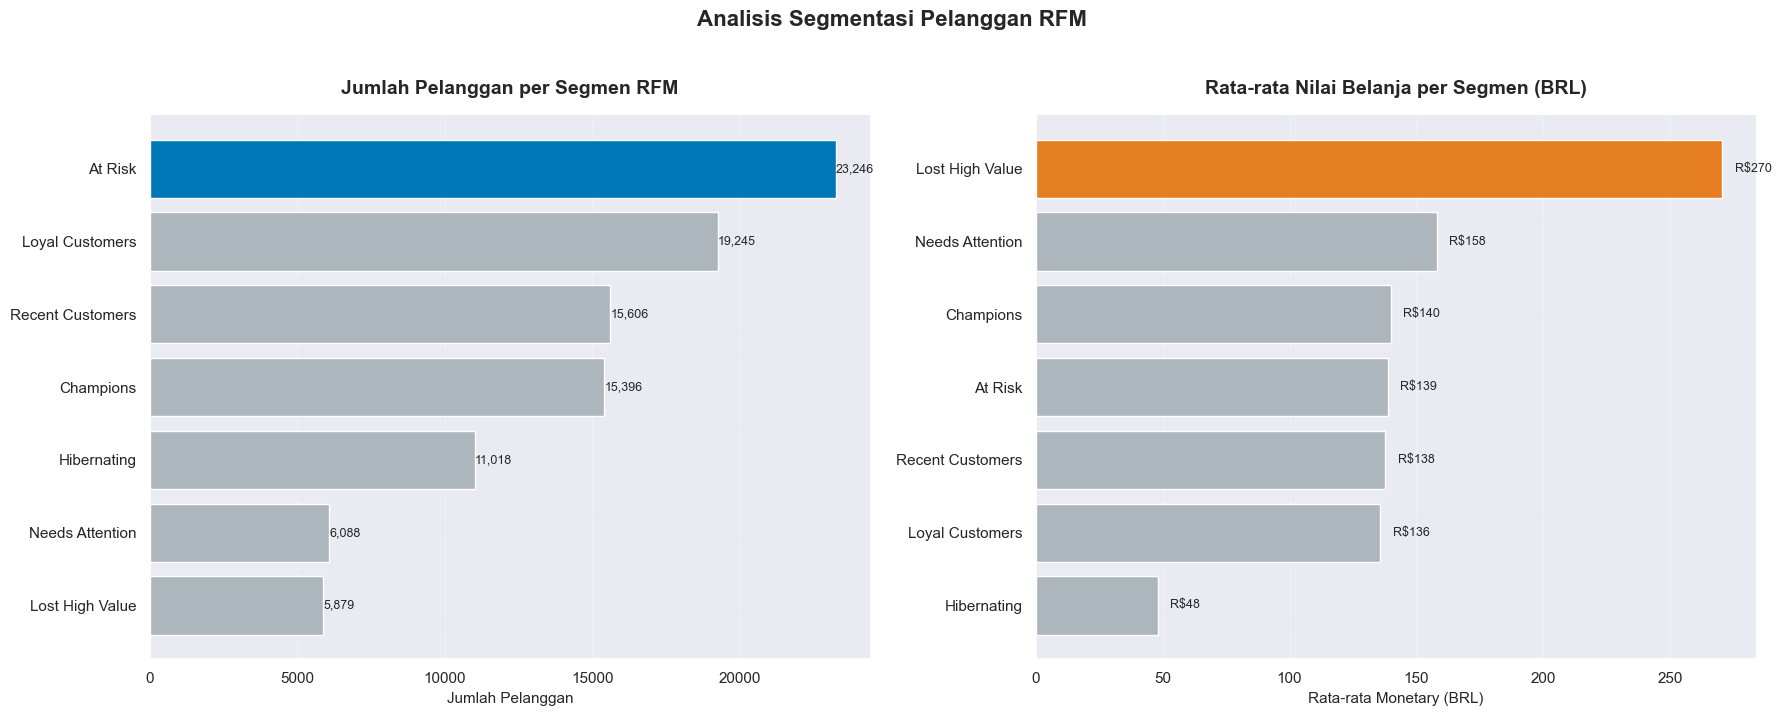

In [206]:
# Distribusi segmen customers
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Kiri: Bar Chart Jumlah per Segmen ---
segment_counts = rfm["segment"].value_counts().reset_index()
segment_counts.columns = ["segment", "count"]

colors_seg = ["#0077b6" if i == 0 else "#adb5bd" for i in range(len(segment_counts))]

axes[0].barh(
    segment_counts["segment"][::-1],
    segment_counts["count"][::-1],
    color=colors_seg[::-1]
)
axes[0].set_title("Jumlah Pelanggan per Segmen RFM", fontsize=14, fontweight="bold", pad=15)
axes[0].set_xlabel("Jumlah Pelanggan", fontsize=11)
axes[0].set_ylabel(None)
axes[0].grid(axis="x", linestyle="--", alpha=0.4)
axes[0].spines[["top", "right"]].set_visible(False)

for i, v in enumerate(segment_counts["count"][::-1]):
    axes[0].text(v + 10, i, f"{v:,}", va="center", fontsize=9)

# --- Kanan: Rata-rata Monetary per Segmen ---
segment_monetary = rfm.groupby("segment")["monetary"].mean().reset_index()
segment_monetary = segment_monetary.sort_values("monetary", ascending=False)

colors_mon = ["#e67e22" if i == 0 else "#adb5bd" for i in range(len(segment_monetary))]

axes[1].barh(
    segment_monetary["segment"][::-1],
    segment_monetary["monetary"][::-1],
    color=colors_mon[::-1]
)
axes[1].set_title("Rata-rata Nilai Belanja per Segmen (BRL)", fontsize=14, fontweight="bold", pad=15)
axes[1].set_xlabel("Rata-rata Monetary (BRL)", fontsize=11)
axes[1].set_ylabel(None)
axes[1].grid(axis="x", linestyle="--", alpha=0.4)
axes[1].spines[["top", "right"]].set_visible(False)

for i, v in enumerate(segment_monetary["monetary"][::-1]):
    axes[1].text(v + 5, i, f"R${v:,.0f}", va="center", fontsize=9)

plt.suptitle("Analisis Segmentasi Pelanggan RFM", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

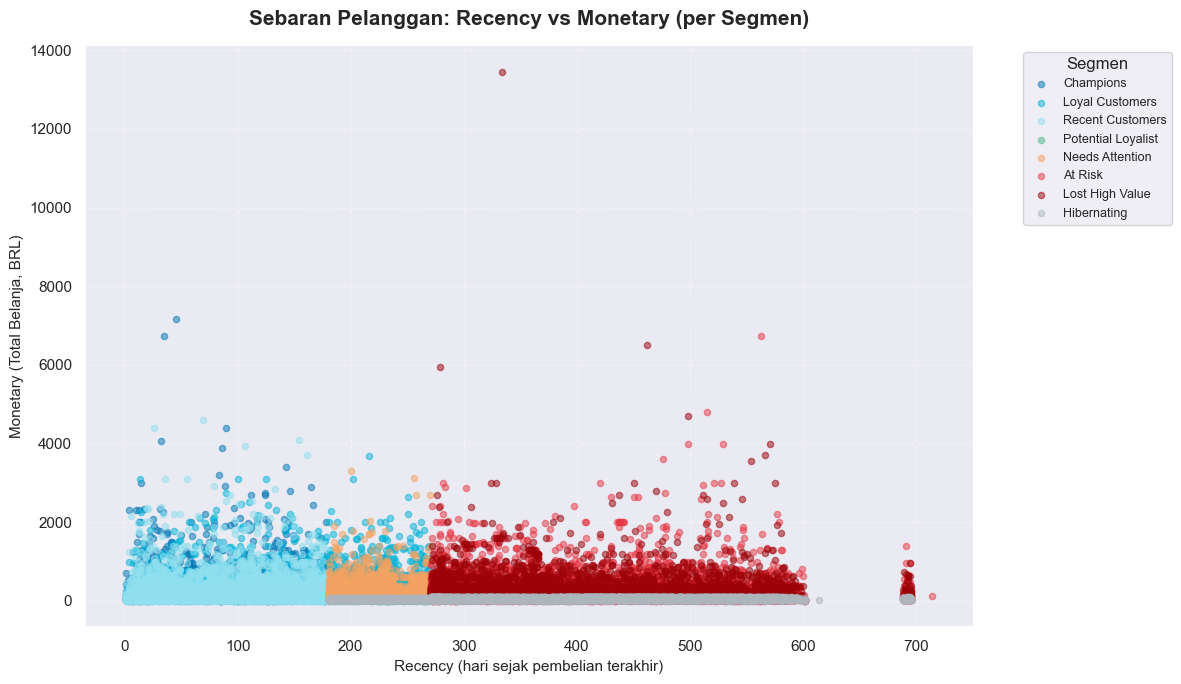

In [207]:
# Scatter plot Recency vs Monetary per segmen
plt.figure(figsize=(12, 7))

segment_colors = {
    "Champions": "#0077b6",
    "Loyal Customers": "#00b4d8",
    "Recent Customers": "#90e0ef",
    "Potential Loyalist": "#52b788",
    "Needs Attention": "#f4a261",
    "At Risk": "#e63946",
    "Lost High Value": "#9d0208",
    "Hibernating": "#adb5bd"
}

for seg, color in segment_colors.items():
    subset = rfm[rfm["segment"] == seg]
    plt.scatter(
        subset["recency"],
        subset["monetary"],
        c=color,
        label=seg,
        alpha=0.5,
        s=20
    )

plt.title("Sebaran Pelanggan: Recency vs Monetary (per Segmen)", 
          fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Recency (hari sejak pembelian terakhir)", fontsize=11)
plt.ylabel("Monetary (Total Belanja, BRL)", fontsize=11)
plt.legend(title="Segmen", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.grid(linestyle="--", alpha=0.3)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

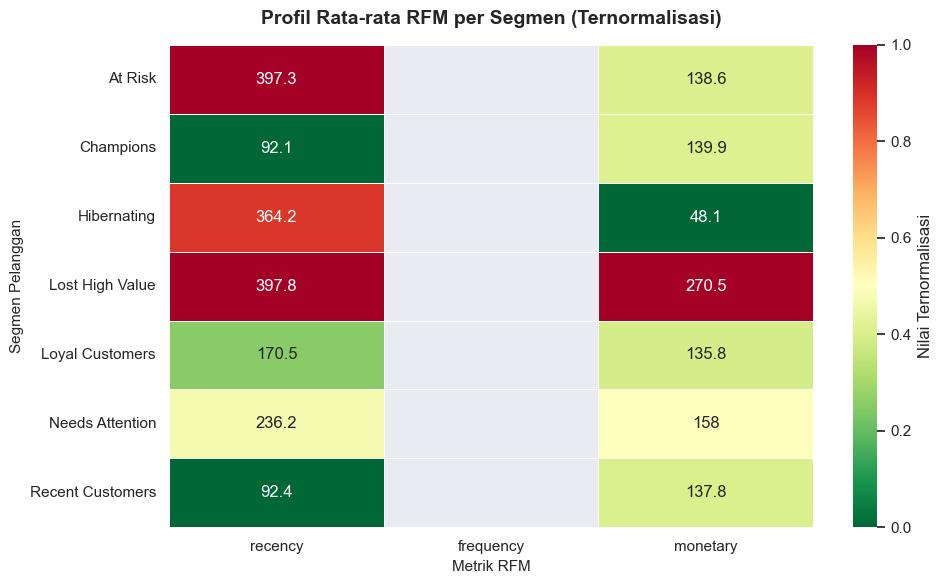

In [208]:
# Heatmap profil rata-rata RFM per segmen
rfm_heatmap = rfm.groupby("segment")[["recency", "frequency", "monetary"]].mean()

# Normalisasi untuk visualisasi
rfm_heatmap_norm = (rfm_heatmap - rfm_heatmap.min()) / (rfm_heatmap.max() - rfm_heatmap.min())

plt.figure(figsize=(10, 6))
sns.heatmap(
    rfm_heatmap_norm,
    annot=rfm_heatmap.round(1),  # tampilkan nilai asli
    fmt="g",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Nilai Ternormalisasi"}
)
plt.title("Profil Rata-rata RFM per Segmen (Ternormalisasi)", 
          fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Metrik RFM", fontsize=11)
plt.ylabel("Segmen Pelanggan", fontsize=11)
plt.tight_layout()
plt.show()

In [209]:
# Simpan RFM data
rfm.to_csv("rfm_data.csv", index=False)
print("RFM data berhasil disimpan!")

# Ringkasan segmen
summary = rfm.groupby("segment").agg(
    jumlah_pelanggan=("customer_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_revenue=("monetary", "sum")
).round(2).reset_index()

print(summary.sort_values("total_revenue", ascending=False))

RFM data berhasil disimpan!
            segment  jumlah_pelanggan  avg_recency  avg_frequency  \
0           At Risk             23246       397.31            1.0   
4   Loyal Customers             19245       170.50            1.0   
1         Champions             15396        92.09            1.0   
6  Recent Customers             15606        92.37            1.0   
3   Lost High Value              5879       397.80            1.0   
5   Needs Attention              6088       236.24            1.0   
2       Hibernating             11018       364.22            1.0   

   avg_monetary  total_revenue  
0        138.63     3222578.20  
4        135.76     2612718.34  
1        139.90     2153934.00  
6        137.81     2150637.63  
3        270.47     1590070.72  
5        158.04      962142.00  
2         48.05      529417.22  


### Temuan Analisis RFM:

**Segmen Terbesar:**
- Mayoritas pelanggan masuk kategori `Hibernating` dan `Needs Attention`: Mereka pernah beli tapi sudah lama tidak kembali

**Segmen Paling Berharga:**
- `Champions` & `Loyal Customers` meskipun jumlahnya kecil,
  berkontribusi besar pada total revenue: Prioritas utama untuk program retensi & loyalty reward

**Segmen Peluang:**
- `Recent Customers` — baru beli, belum tentu loyal: Perlu onboarding campaign dan cross-sell produk relevan

**Segmen Darurat:**
- `At Risk` & `Lost High Value` — pernah belanja banyak tapi lama hilang: Butuh win-back campaign dengan diskon eksklusif

### Rekomendasi Bisnis:
| Segmen | Strategi |
|--------|----------|
| Champions | Loyalty program, early access produk baru |
| Loyal Customers | Reward poin, referral program |
| Recent Customers | Welcome email series, product recommendation |
| Needs Attention | Re-engagement campaign, reminder |
| At Risk | Diskon terbatas waktu, survei kepuasan |
| Lost High Value | Win-back campaign agresif, penawaran spesial |
| Hibernating | Email reaktivasi atau hapus dari daftar aktif |

## Conclusion

- Conclution pertanyaan 1
Kategori bed_bath_table memiliki volume penjualan tertinggi (~10.000+ pesanan), menjadikannya penggerak utama transaksi harian. Namun dari sisi pendapatan, health_beauty dan watches_gifts menghasilkan revenue terbesar, mengindikasikan produk-produk tersebut memiliki nilai per unit yang lebih tinggi. Rekomendasi: optimalkan stok bed_bath_table untuk volume, dan tingkatkan promosi watches_gifts untuk margin keuntungan.
- Conclution pertanyaan 2
Pesanan paling banyak terjadi pada pukul 10:00–17:00 (jam kerja/istirahat siang), dengan puncak tertinggi di siang hari. Hari Senin dan Selasa adalah hari paling aktif. Rekomendasi: jadwalkan iklan/notifikasi push pada rentang waktu tersebut untuk memaksimalkan konversi.